# Stage 2: Final Calibration on All Storms

**Purpose:** Using the winning objective set identified in Stage 1, run the final
calibration on all N storms simultaneously and extract the full Pareto ensemble.

## Workflow
1. Load or re-run calibration on ALL storm events (shares checkpoint with Stage 1).
2. Compute multi-domain objectives on the full dataset.
3. Find the Pareto front using the winning objective set.
4. Save the **entire Pareto ensemble** (Requirement 3 — full uncertainty ensemble
   is preserved for future analysis).
5. Identify the single Euclidean optimum as the representative parameter set.

## Outputs
| Path | Contents |
|------|----------|
| `outputs/pareto/final/pareto_ensemble_full.csv` | All non-dominated parameter sets |
| `outputs/pareto/final/pareto_optimum.csv` | Single Euclidean-closest solution |
| `outputs/results/final_calibration/combined_objectives.pkl` | Full objective table |


In [19]:
# ── Configuration ────────────────────────────────────────────────────────────
import sys
from pathlib import Path

sys.path.insert(0, str(Path('.').resolve()))

CV_DIR = Path(
    r'D:\Development\RESEARCH\Raanana\SWMM\from_radar\Cross_validation'
)

PROJECT_ROOT = Path('.')
WORK_DIR     = PROJECT_ROOT / 'outputs' / 'runs'    / 'final_calibration'
RESULTS_DIR  = PROJECT_ROOT / 'outputs' / 'results' / 'final_calibration'
PARETO_DIR   = PROJECT_ROOT / 'outputs' / 'pareto'  / 'final'
for _d in [WORK_DIR, RESULTS_DIR, PARETO_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

# Checkpoint shared with Stage 1 (avoids re-running SWMM if Stage 1 was run first)
LOOCV_CACHE      = PROJECT_ROOT / 'outputs' / 'results' / 'loocv' / 'loocv_calibration_cache.pkl'
FINAL_CACHE      = RESULTS_DIR / 'final_calibration_cache.pkl'
OBJECTIVES_CACHE = RESULTS_DIR / 'combined_objectives.pkl'

# Winning objective set from Stage 1 — edit here if using a different set
WINNING_OBJECTIVE_SET = ['peak_1-kge', 'volume_1-kge', 'peak_rmsd', 'peak_bias']

print('Configuration loaded.')
print(f'  Winning objectives : {WINNING_OBJECTIVE_SET}')
print(f'  Pareto output dir  : {PARETO_DIR}')


Configuration loaded.
  Winning objectives : ['peak_1-kge', 'volume_1-kge', 'peak_rmsd', 'peak_bias']
  Pareto output dir  : outputs\pareto\final


In [20]:
# ── Imports ───────────────────────────────────────────────────────────────────
import pickle
import logging
import os
import numpy as np
import pandas as pd

from urban_runoff.config import PARAMETER_GRID, PARETO_ENSEMBLE_FILENAME, PARETO_OPTIMUM_FILENAME
from urban_runoff.calibration.cross_validation import (
    build_factor_combinations,
    run_calibration,
    merge_calibration_results,
)
from urban_runoff.calibration.objectives import (
    compute_objective_functions,
    build_objectives_dataframe,
)
from urban_runoff.optimization.pareto    import find_pareto_front, normalize_columns
from urban_runoff.optimization.selection import (
    closest_row_to_origin,
    save_pareto_ensemble,
)

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s %(levelname)-8s %(name)s: %(message)s',
    datefmt='%H:%M:%S',
)
logger = logging.getLogger('final_calibration_notebook')


In [21]:
# ── Load calibration data (prefer Stage 1 cache, else run fresh) ─────────────
factor_combinations = build_factor_combinations()
param_names         = list(PARAMETER_GRID.keys())

# Stage 1 cache contains the full all-event calibration — reuse it
_cache_to_use = LOOCV_CACHE if LOOCV_CACHE.exists() else FINAL_CACHE

if _cache_to_use.exists():
    logger.info('Loading calibration cache from %s', _cache_to_use)
    with open(_cache_to_use, 'rb') as _f:
        _cached = pickle.load(_f)
    cali_results_df_l = _cached['cali_results_df_l']
    hydrograph_df_l   = _cached['hydrograph_df_l']
    obs_hydrograph_df = _cached['obs_hydrograph_df']
    logger.info('Loaded: %d events, %d combos each.', len(cali_results_df_l), len(cali_results_df_l[0]))
else:
    n_events = sum(1 for e in os.listdir(CV_DIR) if e.split('_')[0].isdigit())
    logger.info('Running full calibration: %d events x %d combos', n_events, len(factor_combinations))
    cali_results_df_l, hydrograph_df_l, obs_hydrograph_df = run_calibration(
        cv_dir=CV_DIR,
        factor_combinations=factor_combinations,
        param_names=param_names,
        work_dir=WORK_DIR,
    )
    with open(FINAL_CACHE, 'wb') as _f:
        pickle.dump({
            'cali_results_df_l': cali_results_df_l,
            'hydrograph_df_l':   hydrograph_df_l,
            'obs_hydrograph_df': obs_hydrograph_df,
        }, _f)
    logger.info('Calibration cache saved to %s', FINAL_CACHE)

print(f'Events : {len(cali_results_df_l)}')
print(f'Combos : {len(cali_results_df_l[0])}')


22:03:02 INFO     final_calibration_notebook: Loading calibration cache from outputs\results\loocv\loocv_calibration_cache.pkl
22:03:02 INFO     final_calibration_notebook: Loaded: 23 events, 480 combos each.


Events : 23
Combos : 480


In [22]:
# ── Merge results and compute objectives (or load from checkpoint) ────────────
if OBJECTIVES_CACHE.exists():
    logger.info('Loading objectives cache from %s', OBJECTIVES_CACHE)
    with open(OBJECTIVES_CACHE, 'rb') as _f:
        _obj_cache = pickle.load(_f)
    cali_merged     = _obj_cache['cali_merged']
    hydro_merged    = _obj_cache['hydro_merged']
    storm_obj_df    = _obj_cache['storm_obj_df']
    peak_obj_df     = _obj_cache['peak_obj_df']
    volume_obj_df   = _obj_cache['volume_obj_df']
else:
    logger.info('Merging calibration results across all events...')
    cali_merged  = merge_calibration_results(cali_results_df_l)
    hydro_merged = merge_calibration_results(hydrograph_df_l)

    logger.info('Computing objectives...')
    storm_obj_df, peak_obj_df, volume_obj_df = compute_objective_functions(
        obs_hydrograph_df, cali_merged, hydro_merged
    )
    with open(OBJECTIVES_CACHE, 'wb') as _f:
        pickle.dump({
            'cali_merged':   cali_merged,
            'hydro_merged':  hydro_merged,
            'storm_obj_df':  storm_obj_df,
            'peak_obj_df':   peak_obj_df,
            'volume_obj_df': volume_obj_df,
        }, _f)
    logger.info('Objectives cache saved to %s', OBJECTIVES_CACHE)

objectives_flat = build_objectives_dataframe(
    storm_obj_df, peak_obj_df, volume_obj_df,
    objective_names=WINNING_OBJECTIVE_SET,
)
print('Objectives computed. Shape:', objectives_flat.shape)
print(objectives_flat[WINNING_OBJECTIVE_SET].describe().round(4))


22:03:02 INFO     final_calibration_notebook: Loading objectives cache from outputs\results\final_calibration\combined_objectives.pkl


Objectives computed. Shape: (480, 4)
       peak_1-kge  volume_1-kge  peak_rmsd  peak_bias
count    480.0000      480.0000   480.0000   480.0000
mean       0.2910        0.5316     6.8782     2.2465
std        0.0783        0.2120     1.1068     1.6473
min        0.1667        0.1193     5.2264     0.0026
25%        0.2284        0.3732     6.0097     0.8661
50%        0.2779        0.5146     6.6088     1.9295
75%        0.3389        0.6789     7.5113     3.3341
max        0.5439        1.0042    11.1089     7.9789


In [ ]:
# ── Physical bounds filter (Directive 2) ─────────────────────────────────────
# Edit FILTER_BOUNDS in urban_runoff/config.py to restrict the Pareto search.
# e.g.  "imperviousness": (1.0, 1.5)  excludes all IMP factors below 1.0.
# The filter operates on the already-cached objective values — no SWMM re-runs.
# Both cali_merged and objectives_flat are trimmed to the same valid row set.

from urban_runoff.config import FILTER_BOUNDS
from urban_runoff.calibration.cross_validation import apply_filter_bounds

_n_before   = len(objectives_flat)
_valid_idx  = apply_filter_bounds(cali_merged, FILTER_BOUNDS)
cali_merged     = cali_merged.loc[_valid_idx]
objectives_flat = objectives_flat.loc[_valid_idx]
_n_after    = len(objectives_flat)

print('Parameter filter applied.')
print(f'  Active bounds : { {k: v for k, v in FILTER_BOUNDS.items() if v is not None} or "none (full grid)"}')
print(f'  Rows before   : {_n_before}')
print(f'  Rows after    : {_n_after}  ({_n_before - _n_after} dropped)')


In [23]:
# ── Pareto front + save full ensemble (Requirement 3) ────────────────────────
pareto_obj_df = find_pareto_front(objectives_flat, normalize=True)

print(f'Total combinations : {len(objectives_flat)}')
print(f'Pareto front size  : {len(pareto_obj_df)} ({100*len(pareto_obj_df)/len(objectives_flat):.1f}%)')

# Save both the full ensemble and the single optimum
save_pareto_ensemble(
    pareto_obj_df=pareto_obj_df,
    full_calibration_df=cali_merged,
    output_dir=PARETO_DIR,
    ensemble_filename=PARETO_ENSEMBLE_FILENAME,
    optimum_filename=PARETO_OPTIMUM_FILENAME,
)
print(f'Full ensemble -> {PARETO_DIR / PARETO_ENSEMBLE_FILENAME}')
print(f'Single optimum-> {PARETO_DIR / PARETO_OPTIMUM_FILENAME}')


22:03:02 INFO     urban_runoff.optimization.pareto: find_pareto_front: 33/480 solutions are Pareto-optimal (6.9%)
22:03:02 INFO     urban_runoff.optimization.selection: Saved Pareto ensemble (33 members) to outputs\pareto\final\pareto_ensemble_full.csv
22:03:02 INFO     urban_runoff.optimization.selection: Saved Pareto optimum (index 107) to outputs\pareto\final\pareto_optimum.csv


Total combinations : 480
Pareto front size  : 33 (6.9%)
Full ensemble -> outputs\pareto\final\pareto_ensemble_full.csv
Single optimum-> outputs\pareto\final\pareto_optimum.csv


In [24]:
# ── Inspect the Euclidean optimum ────────────────────────────────────────────
optimum_row = closest_row_to_origin(pareto_obj_df)
optimum_full = cali_merged.loc[optimum_row.name]

print('=== Pareto Optimum (Euclidean closest to origin) ===')
print()
factor_cols = [c for c in cali_merged.columns if c[0] == 'Factors']
print('Factor values:')
for col in factor_cols:
    print(f'  {col[1]:<12}: {optimum_full[col]:.4f}')
print()
print('Objective values (normalised):')
for obj_name in WINNING_OBJECTIVE_SET:
    print(f'  {obj_name:<18}: {pareto_obj_df.loc[optimum_row.name, obj_name]:.4f}')


=== Pareto Optimum (Euclidean closest to origin) ===

Factor values:
  IMP         : 1.0000
  Storage     : 7.0000
  Width       : 0.7000
  N           : 1.0000
  PCT_ZERO    : 1.0000
  CN          : 1.0000
  PCT_ROUTED  : 35.0000
  EVAP        : 4.0000

Objective values (normalised):
  peak_1-kge        : 0.0855
  volume_1-kge      : 0.0596
  peak_rmsd         : 0.0500
  peak_bias         : 0.0599


## Visualization

All plots read from variables computed in the cells above — no SWMM re-runs.

| Figure | File |
|--------|------|
| Pareto front (all pairs) | `outputs/metrics/final_pareto_grid.png` |
| Final calibration scatter | `outputs/metrics/final_calibration_scatter.png` |


In [25]:
# ── Visualization setup — normalize objectives for plot axes ─────────────────
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

from urban_runoff.optimization.pareto        import normalize_columns
from urban_runoff.visualization.pareto_plots import plot_pareto_grid
from urban_runoff.visualization.scatter      import plot_performance_scatter
import matplotlib.pyplot as plt

METRICS_DIR = PROJECT_ROOT / 'outputs' / 'metrics'
METRICS_DIR.mkdir(parents=True, exist_ok=True)

# Normalize for display — Pareto dominance was found on normalized data,
# so visualizing on the same [0, 1] scale matches the legacy notebook style.
_objectives_norm = normalize_columns(objectives_flat.abs())
_pareto_norm     = _objectives_norm.loc[pareto_obj_df.index]
_optimum_norm    = _objectives_norm.loc[optimum_row.name]

print(f'Objective range after normalization: '
      f'[{_objectives_norm.min().min():.3f}, {_objectives_norm.max().max():.3f}]')
print(f'Pareto front: {len(pareto_obj_df)} points  |  '
      f'Optimum index: {optimum_row.name}')


Objective range after normalization: [0.000, 1.000]
Pareto front: 33 points  |  Optimum index: 107


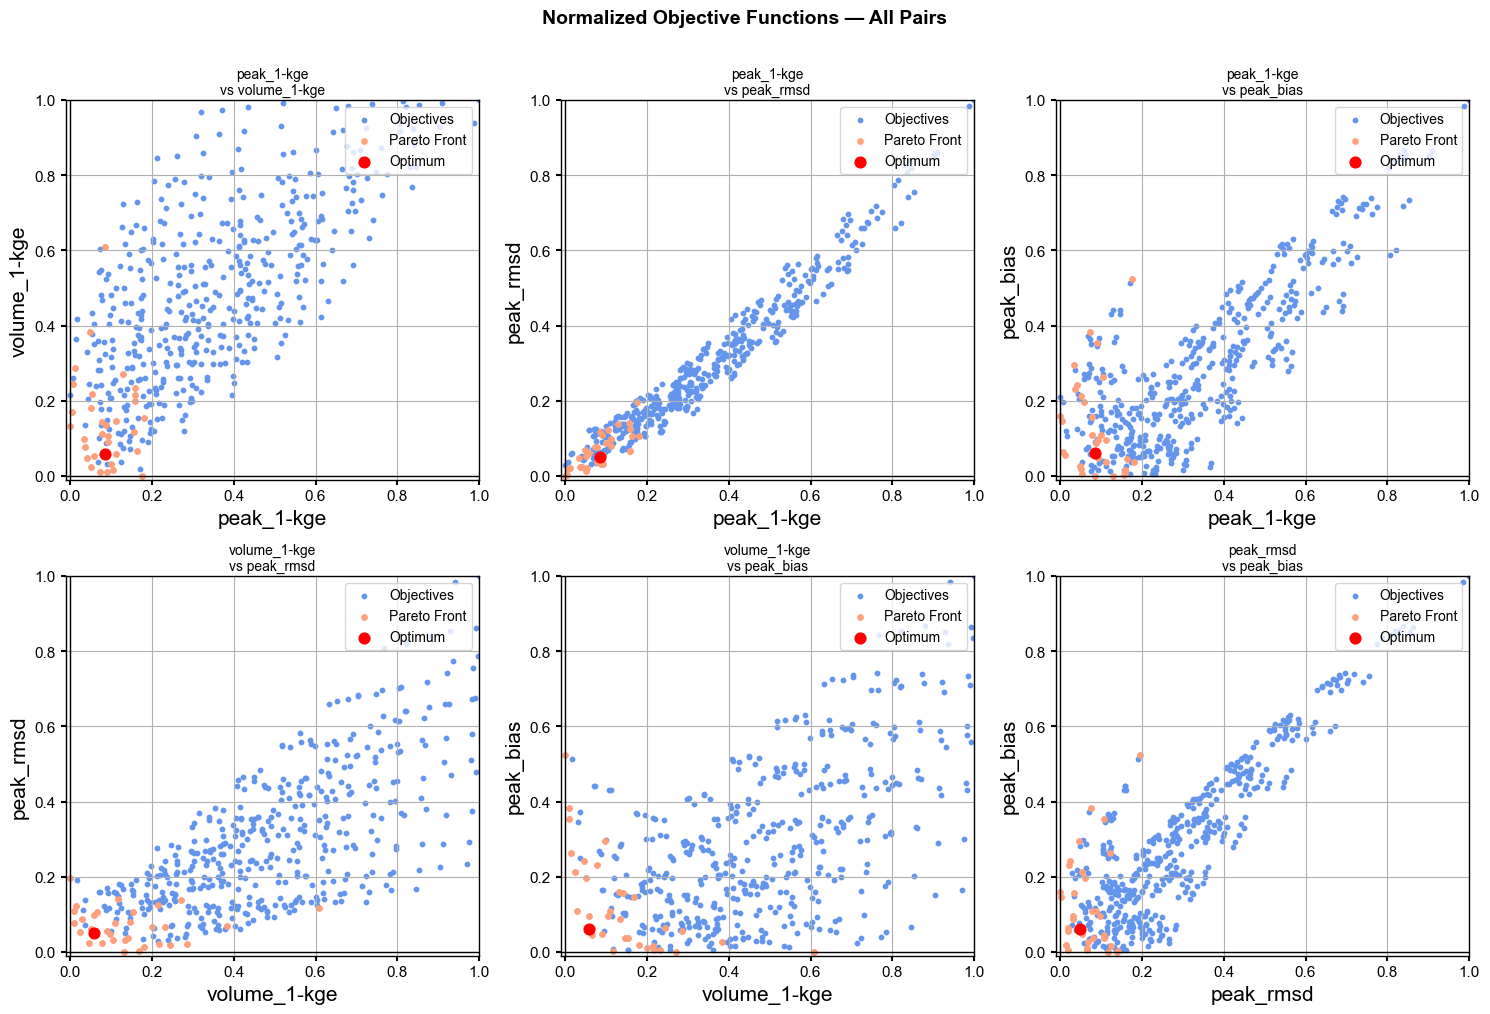

Saved -> outputs\metrics\final_pareto_grid.png


In [26]:
# ── Plot 1: Pareto front — all objective pairs ───────────────────────────────
fig_pareto = plot_pareto_grid(
    objectives_df   = _objectives_norm,
    pareto_df       = _pareto_norm,
    optimum_row     = _optimum_norm,
    objective_names = WINNING_OBJECTIVE_SET,
    save_path       = str(METRICS_DIR / 'final_pareto_grid.png'),
)
plt.show()
print(f'Saved -> {METRICS_DIR / "final_pareto_grid.png"}')


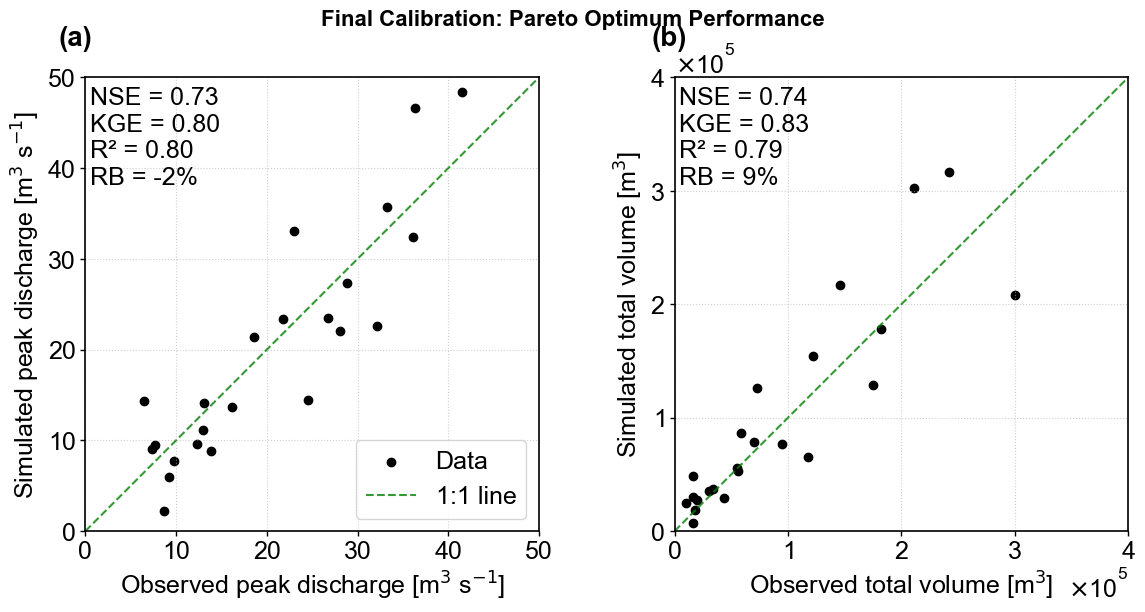

Saved -> outputs\metrics\final_calibration_scatter.png
Events in scatter: 23


In [27]:
# ── Plot 2: Final calibration performance scatter (obs vs sim) ───────────────
# Extract per-event peak and volume values for the Pareto optimum parameter set.
obs_max_runoff = obs_hydrograph_df.groupby(level=0)['OBS runoff [CMS]'].max()
obs_total_vol  = obs_hydrograph_df.groupby(level=0)['OBS runoff [CMS]'].sum() * 5 * 60

sim_peaks_s = cali_merged.xs('Max Runoff',   level=1, axis=1).loc[optimum_row.name]
sim_vols_s  = cali_merged.xs('Total Volume', level=1, axis=1).loc[optimum_row.name] * 5 * 60

# Align by date index to guarantee consistent ordering
dates         = obs_max_runoff.index
obs_peaks_arr = obs_max_runoff[dates].values.astype(float)
sim_peaks_arr = sim_peaks_s[dates].values.astype(float)
obs_vols_arr  = obs_total_vol[dates].values.astype(float)
sim_vols_arr  = sim_vols_s[dates].values.astype(float)

fig_perf = plot_performance_scatter(
    obs_peaks    = obs_peaks_arr,
    sim_peaks    = sim_peaks_arr,
    obs_volumes  = obs_vols_arr,
    sim_volumes  = sim_vols_arr,
    title_suffix = 'Final Calibration: Pareto Optimum Performance',
    save_path    = str(METRICS_DIR / 'final_calibration_scatter.png'),
)
plt.show()
print(f'Saved -> {METRICS_DIR / "final_calibration_scatter.png"}')
print(f'Events in scatter: {len(obs_peaks_arr)}')


## Hydrograph Plots

`plot_hydrograph()` renders observed vs simulated discharge for any storm event
at the Pareto optimum parameter set (or any other row index).  Reads directly
from the calibration cache — no SWMM re-runs.

Set `EVENT_DATE` below to any of the 23 storm dates, then run the cell.
To loop over all events, replace the single call with the loop cell below.

In [ ]:
# ── Hydrograph — single event ─────────────────────────────────────────────────
from urban_runoff.visualization.scatter import plot_hydrograph

# Change EVENT_DATE to any storm date from the CV directory (YYYY_MM_DD format).
EVENT_DATE = sorted(
    e for e in __import__('os').listdir(str(CV_DIR)) if e.split('_')[0].isdigit()
)[0]   # defaults to first (earliest) event; replace with any date string

print(f'Plotting hydrograph for event: {EVENT_DATE}')
print(f'Parameter set (row {optimum_row.name}): Pareto optimum')

fig_hydro = plot_hydrograph(
    event_date        = EVENT_DATE,
    obs_hydrograph_df = obs_hydrograph_df,
    hydro_merged      = hydro_merged,
    row_idx           = optimum_row.name,
    title_suffix      = 'Pareto Optimum',
    save_path         = str(METRICS_DIR / f'hydrograph_{EVENT_DATE}.png'),
)
plt.show()
print(f'Saved -> {METRICS_DIR / f"hydrograph_{EVENT_DATE}.png"}')


In [ ]:
# ── Hydrograph — all 23 events ────────────────────────────────────────────────
# Uncomment to generate one hydrograph PNG per event for the Pareto optimum.

# _all_dates = sorted(
#     e for e in __import__('os').listdir(str(CV_DIR)) if e.split('_')[0].isdigit()
# )
# for _date in _all_dates:
#     _fig = plot_hydrograph(
#         event_date        = _date,
#         obs_hydrograph_df = obs_hydrograph_df,
#         hydro_merged      = hydro_merged,
#         row_idx           = optimum_row.name,
#         title_suffix      = 'Pareto Optimum',
#         save_path         = str(METRICS_DIR / f'hydrograph_{_date}.png'),
#     )
#     plt.close(_fig)
# print(f'All hydrographs saved to {METRICS_DIR}')
